In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Modeling
from prophet import Prophet
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error
import joblib
import os

plt.rcParams['figure.figsize'] = (14, 5)
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
import duckdb
import pandas as pd

db_path = r"C:\Users\oorko\OneDrive\Documents\projects\Sales_Forecasting\data\sales_forecast.db"

conn = duckdb.connect(db_path)

df = conn.execute("""
    SELECT *
    FROM mart_sales_features
    WHERE sales_lag_7 IS NOT NULL
    ORDER BY date, store_nbr, family
""").fetchdf()

conn.close()

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Columns: {list(df.columns)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Shape: (2988414, 25)
Date range: 2013-01-08 00:00:00 to 2017-08-15 00:00:00
Columns: ['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'is_weekend', 'quarter', 'city', 'state', 'store_type', 'cluster', 'oil_price', 'is_national_holiday', 'holiday_name', 'transactions', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_7day_avg', 'sales_rolling_28day_avg']


In [3]:
def rmsle(y_true, y_pred):
    """
    Root Mean Squared Log Error - the official competition metric.
    Log transform reduces the impact of large sale outliers.
    Clips predictions at 0 to avoid log of negative number.
    """
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

print("RMSLE function defined")

RMSLE function defined


In [4]:
# Prophet works best on a single time series
# Start with Store 1, GROCERY I (highest volume family)
store_nbr = 1
family = 'GROCERY I'

prophet_df = df[
    (df['store_nbr'] == store_nbr) & 
    (df['family'] == family)
][['date', 'sales']].copy()

# Prophet requires columns named exactly 'ds' and 'y'
prophet_df = prophet_df.rename(columns={'date': 'ds', 'sales': 'y'})
prophet_df = prophet_df.sort_values('ds').reset_index(drop=True)

print(f"Prophet dataset: {prophet_df.shape}")
print(prophet_df.head())

Prophet dataset: (1677, 2)
          ds       y
0 2013-01-08  1782.0
1 2013-01-09  2429.0
2 2013-01-10  1544.0
3 2013-01-11  1750.0
4 2013-01-12  1796.0


In [5]:
# Use last 60 days as test set
split_date = prophet_df['ds'].max() - pd.Timedelta(days=60)

train_prophet = prophet_df[prophet_df['ds'] <= split_date]
test_prophet = prophet_df[prophet_df['ds'] > split_date]

print(f"Train: {train_prophet.shape[0]} rows ({train_prophet['ds'].min().date()} to {train_prophet['ds'].max().date()})")
print(f"Test:  {test_prophet.shape[0]} rows ({test_prophet['ds'].min().date()} to {test_prophet['ds'].max().date()})")

Train: 1617 rows (2013-01-08 to 2017-06-16)
Test:  60 rows (2017-06-17 to 2017-08-15)


In [6]:
model_prophet = Prophet(
    yearly_seasonality=True,   # captures annual patterns (Christmas spike etc.)
    weekly_seasonality=True,   # captures day-of-week patterns
    daily_seasonality=False,   # not needed (data is already daily aggregated)
    seasonality_mode='multiplicative',  # seasonality scales with trend level
    changepoint_prior_scale=0.05        # how flexible the trend line is
)

model_prophet.fit(train_prophet)
print("Prophet model trained successfully")

09:19:50 - cmdstanpy - INFO - Chain [1] start processing
09:19:51 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully


In [7]:
# Create future dataframe covering the test period
future = model_prophet.make_future_dataframe(periods=60)

# Generate forecast
forecast = model_prophet.predict(future)

# Extract test period predictions
forecast_test = forecast[forecast['ds'] > split_date][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_test = forecast_test.merge(test_prophet, on='ds')

print(forecast_test.head(10))

          ds         yhat   yhat_lower   yhat_upper       y
0 2017-06-17  2840.273738  2250.746834  3451.248532  3016.0
1 2017-06-18  1269.293053   658.985204  1865.088533  1223.0
2 2017-06-19  2873.484183  2264.840962  3457.858666  3373.0
3 2017-06-20  2911.313907  2275.459183  3509.138473  4575.0
4 2017-06-21  3328.692651  2755.585061  3975.655222  2898.0
5 2017-06-22  2670.607028  2096.283727  3288.944760  2499.0
6 2017-06-23  2893.071795  2271.866403  3470.529539  2663.0
7 2017-06-24  2764.115582  2185.698149  3371.059658  2877.0
8 2017-06-25  1188.357543   601.746471  1800.307643  1264.0
9 2017-06-26  2793.641868  2145.457987  3387.758101  2812.0


In [8]:
# Clip negative predictions (sales can't be negative)
forecast_test['yhat'] = forecast_test['yhat'].clip(lower=0)

prophet_rmsle = rmsle(forecast_test['y'], forecast_test['yhat'])
print(f"Prophet RMSLE: {prophet_rmsle:.4f}")

Prophet RMSLE: 0.1508


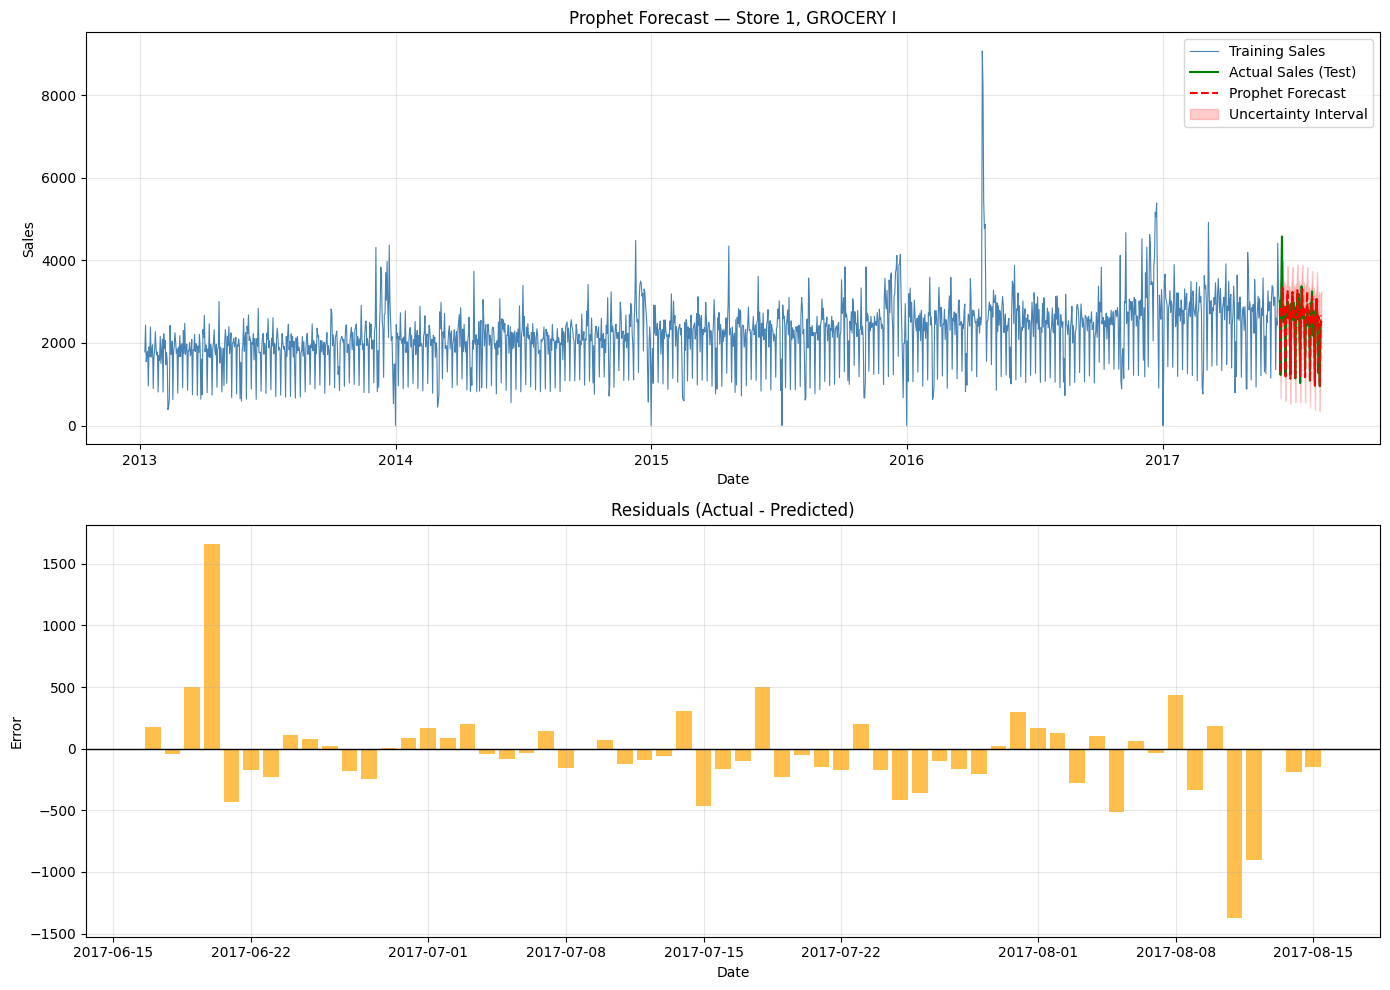

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Forecast vs Actual
axes[0].plot(train_prophet['ds'], train_prophet['y'], 
             color='steelblue', linewidth=0.8, label='Training Sales')
axes[0].plot(test_prophet['ds'], test_prophet['y'], 
             color='green', linewidth=1.5, label='Actual Sales (Test)')
axes[0].plot(forecast_test['ds'], forecast_test['yhat'], 
             color='red', linewidth=1.5, linestyle='--', label='Prophet Forecast')
axes[0].fill_between(forecast_test['ds'], 
                      forecast_test['yhat_lower'], 
                      forecast_test['yhat_upper'], 
                      alpha=0.2, color='red', label='Uncertainty Interval')
axes[0].set_title(f'Prophet Forecast — Store {store_nbr}, {family}')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (actual - predicted)
residuals = test_prophet['y'].values - forecast_test['yhat'].values
axes[1].bar(forecast_test['ds'], residuals, color='orange', alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Residuals (Actual - Predicted)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

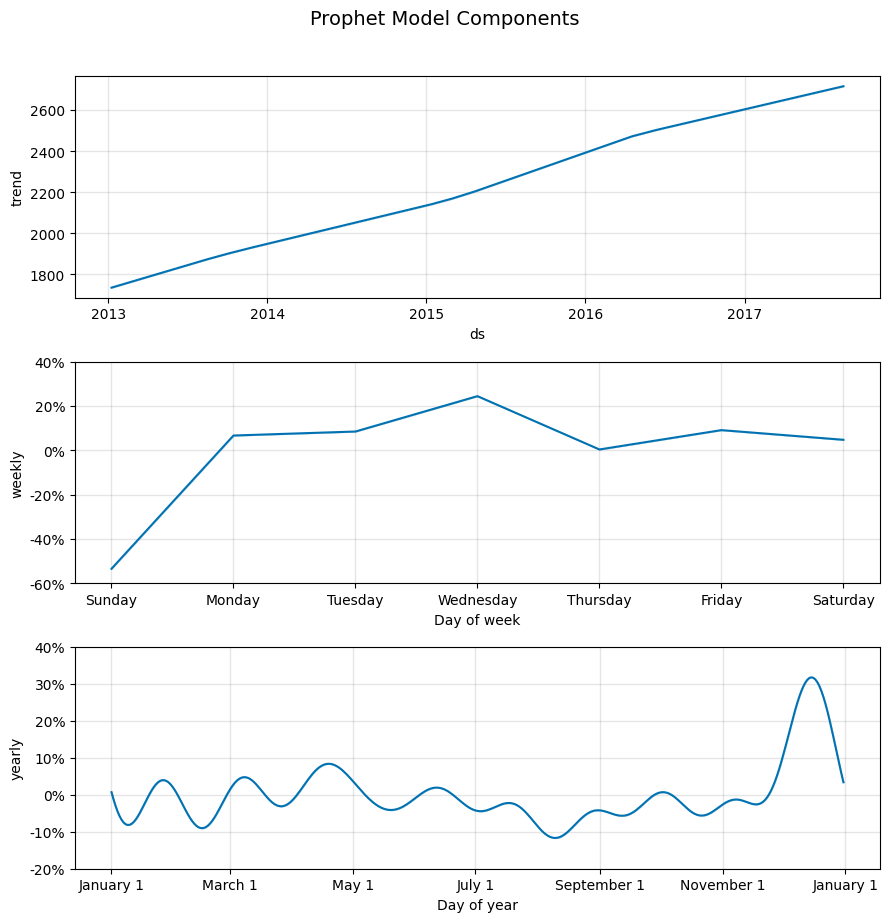

In [10]:
model_prophet.plot_components(forecast)
plt.suptitle('Prophet Model Components', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# XGBoost can use the full dataset across all stores and families
# Select feature columns
feature_cols = [
    'store_nbr', 'family',
    'year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter',
    'is_weekend', 'onpromotion',
    'store_type', 'cluster',
    'oil_price',
    'is_national_holiday',
    'transactions',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'sales_rolling_7day_avg', 'sales_rolling_28day_avg'
]

target_col = 'sales'

# Encode categorical columns (XGBoost needs numbers, not text)
xgb_df = df[feature_cols + [target_col, 'date']].copy()

le_family = LabelEncoder()
le_store_type = LabelEncoder()

xgb_df['family'] = le_family.fit_transform(xgb_df['family'])
xgb_df['store_type'] = le_store_type.fit_transform(xgb_df['store_type'])

print("Feature columns:", feature_cols)
print(f"\nDataset shape: {xgb_df.shape}")
print(f"Unique families encoded: {le_family.classes_}")

Feature columns: ['store_nbr', 'family', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'onpromotion', 'store_type', 'cluster', 'oil_price', 'is_national_holiday', 'transactions', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_7day_avg', 'sales_rolling_28day_avg']

Dataset shape: (2988414, 22)
Unique families encoded: ['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


In [12]:
# Split by date: train on everything before July 2017, test on July-Aug 2017
split_date_xgb = pd.Timestamp('2017-07-01')

train_xgb = xgb_df[xgb_df['date'] < split_date_xgb]
test_xgb  = xgb_df[xgb_df['date'] >= split_date_xgb]

X_train = train_xgb[feature_cols]
y_train = train_xgb[target_col]

X_test = test_xgb[feature_cols]
y_test = test_xgb[target_col]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train date range: {train_xgb['date'].min().date()} to {train_xgb['date'].max().date()}")
print(f"Test date range:  {test_xgb['date'].min().date()} to {test_xgb['date'].max().date()}")

Train: (2906442, 20) | Test: (81972, 20)
Train date range: 2013-01-08 to 2017-06-30
Test date range:  2017-07-01 to 2017-08-15


In [13]:
model_xgb = xgb.XGBRegressor(
    n_estimators=500,        # number of trees
    learning_rate=0.05,      # how much each tree corrects the previous
    max_depth=6,             # how deep each tree can grow
    subsample=0.8,           # fraction of rows used per tree (prevents overfitting)
    colsample_bytree=0.8,    # fraction of features used per tree
    min_child_weight=1,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

print("Training XGBoost... (this may take 1-2 minutes)")
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100  # print progress every 100 trees
)

print("\nXGBoost training complete")

Training XGBoost... (this may take 1-2 minutes)
[0]	validation_0-rmse:1260.11078
[100]	validation_0-rmse:198.23159
[200]	validation_0-rmse:193.92882
[300]	validation_0-rmse:190.78905
[400]	validation_0-rmse:188.96902
[499]	validation_0-rmse:189.90890

XGBoost training complete


In [14]:
xgb_preds = model_xgb.predict(X_test)
xgb_preds = np.clip(xgb_preds, 0, None)  # no negative predictions

xgb_rmsle = rmsle(y_test, xgb_preds)

print("=== MODEL COMPARISON ===")
print(f"Prophet RMSLE:  {prophet_rmsle:.4f}  (Store 1, GROCERY I only)")
print(f"XGBoost RMSLE:  {xgb_rmsle:.4f}  (All stores, all families)")
print("\nLower RMSLE = better. Kaggle leaderboard top score is ~0.376")

=== MODEL COMPARISON ===
Prophet RMSLE:  0.1508  (Store 1, GROCERY I only)
XGBoost RMSLE:  0.6363  (All stores, all families)

Lower RMSLE = better. Kaggle leaderboard top score is ~0.376


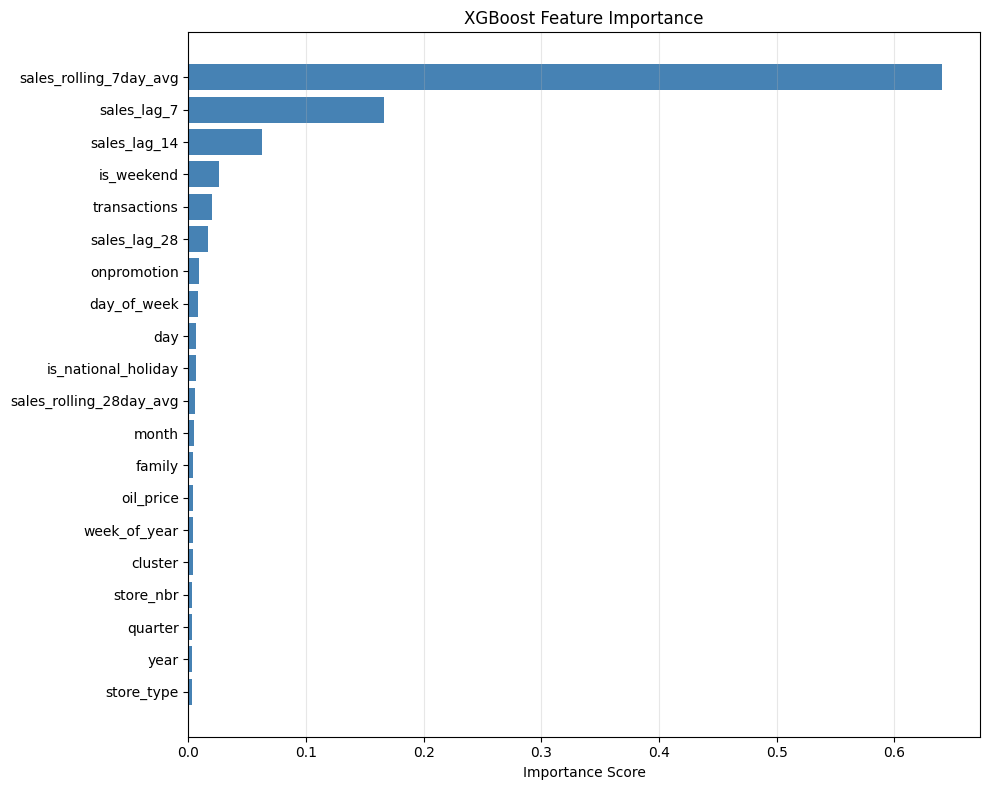

                    feature  importance
18   sales_rolling_7day_avg    0.640876
15              sales_lag_7    0.165936
16             sales_lag_14    0.062517
8                is_weekend    0.025884
14             transactions    0.020528
17             sales_lag_28    0.016929
9               onpromotion    0.008683
5               day_of_week    0.007916
4                       day    0.006261
13      is_national_holiday    0.006186
19  sales_rolling_28day_avg    0.006022
3                     month    0.004795
1                    family    0.004090
12                oil_price    0.003900
6              week_of_year    0.003645
11                  cluster    0.003591
0                 store_nbr    0.003183
7                   quarter    0.003054
2                      year    0.003021
10               store_type    0.002985


In [15]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(importance)

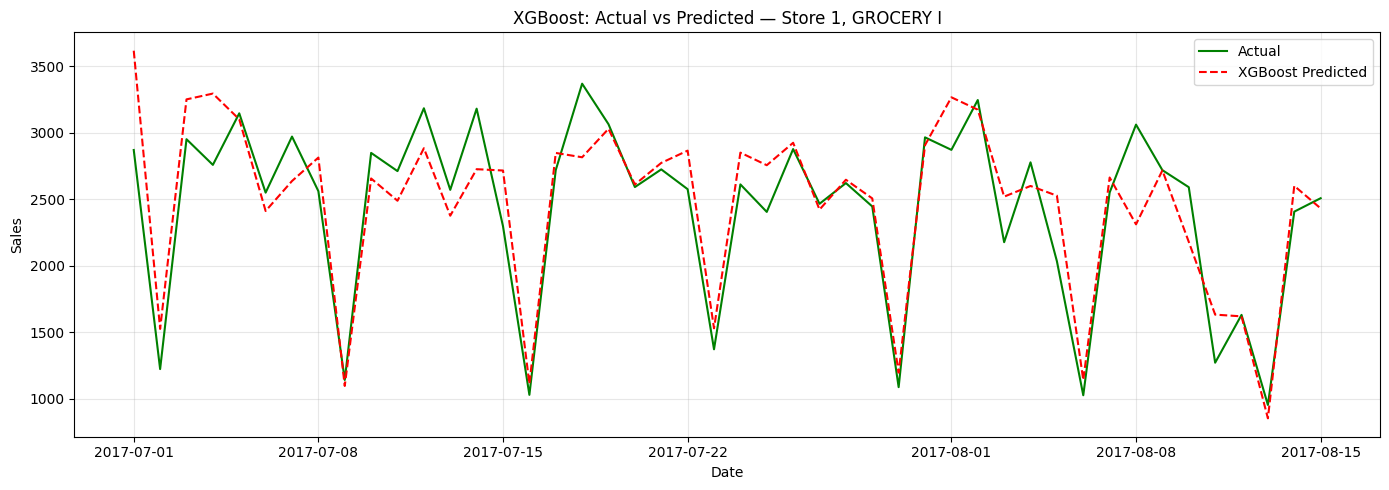

In [16]:
# Sample one store+family for a clean visualization
sample_mask = (test_xgb['store_nbr'] == 1) & (xgb_df.loc[test_xgb.index, 'family'] == le_family.transform(['GROCERY I'])[0])

sample_actual = y_test[sample_mask].values
sample_pred   = xgb_preds[sample_mask]
sample_dates  = test_xgb.loc[sample_mask, 'date']

plt.figure(figsize=(14, 5))
plt.plot(sample_dates, sample_actual, label='Actual', color='green', linewidth=1.5)
plt.plot(sample_dates, sample_pred,   label='XGBoost Predicted', color='red', 
         linewidth=1.5, linestyle='--')
plt.title('XGBoost: Actual vs Predicted — Store 1, GROCERY I')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
import os
import joblib

models_dir = r"C:\Users\oorko\OneDrive\Documents\projects\Sales_Forecasting\models"

# Create models directory
os.makedirs(models_dir, exist_ok=True)

# Save XGBoost model
joblib.dump(model_xgb, os.path.join(models_dir, "xgb_model.pkl"))

# Save Prophet model
joblib.dump(model_prophet, os.path.join(models_dir, "prophet_model.pkl"))

# Save label encoders
joblib.dump(le_family, os.path.join(models_dir, "le_family.pkl"))
joblib.dump(le_store_type, os.path.join(models_dir, "le_store_type.pkl"))

# Save feature column order
joblib.dump(feature_cols, os.path.join(models_dir, "feature_cols.pkl"))

print("Models saved:")

for f in os.listdir(models_dir):
    file_path = os.path.join(models_dir, f)
    size = os.path.getsize(file_path) / 1024
    print(f"  {f} ({size:.1f} KB)")

Models saved:
  feature_cols.pkl (0.3 KB)
  le_family.pkl (0.9 KB)
  le_store_type.pkl (0.5 KB)
  prophet_model.pkl (149.4 KB)
  xgb_model.pkl (2032.7 KB)
